In [ ]:
import os
import pandas as pd
from docx import Document
from sentence_transformers import SentenceTransformer, util
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import random
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import json
import re

c:\Users\Majo\anaconda3\envs\sentencias\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuración inicial

In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

Usando dispositivo: cuda


In [3]:
# === CONFIGURACIÓN ===
PATH_EXCEL = "entrevistas.xlsx"
PATH_ENTREVISTAS = "entrevistas/"
MODEL_NAME = "intfloat/e5-large"
TOP_K = 2
SIM_THRESHOLD = 0.75  # umbral para conectar fragmentos entre sí

In [4]:
# === CARGAR MODELO DE EMBEDDINGS ===
model = SentenceTransformer(MODEL_NAME, device='cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
import re
import unicodedata

# Patrones de muletillas o expresiones de ruido a eliminar
PATRONES_RUIDO = [
    r'\bokey\b', r'\bOkey\b', r'\bok\b', r'\buf+\b', r'\bem+\b', r'\bok+\b', r'\be+\b', r'\bau+\b', r'\bah+\b', r'\beh+\b',
    r'\buh+\b', r'\boh+\b', r'\byy+\b', r'\baja+\b', r'\beee+\b', r'\bmmm+\b', r'\bpor ejemplo\b', r'\bujum+\b', r'\blisto+\b'
]

# Stopwords básicas en español (puedes expandirlas según necesites)

def normalizar_texto(texto):
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    texto = unicodedata.normalize('NFKC', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c)[0] != 'C')
    return texto

def reducir_repeticiones(palabra):
    excepciones = {'l', 's', 'o', 'r', 'c','e'}
    resultado = ''
    i = 0
    while i < len(palabra):
        actual = palabra[i]
        j = i + 1
        while j < len(palabra) and palabra[j] == actual:
            j += 1
        repeticiones = j - i
        if repeticiones >= 2 and actual not in excepciones:
            resultado += actual
        else:
            resultado += palabra[i:j]
        i = j
    return resultado

def preprocesar_texto_sin_lematizar(texto):
    """Limpia y normaliza el texto, manteniendo etiquetas como 'E:' o 'P:'. Devuelve lista de líneas limpias."""
    if not isinstance(texto, str):
        return []

    lineas = texto.split('\n')
    lineas_limpias = []

    for linea in lineas:
        linea = linea.strip()
        if not linea:
            continue

        # Verificar si tiene etiqueta tipo "E:" o "P:"
        if linea.startswith(('E:', 'P:')) and len(linea) > 2:
            etiqueta = linea[:2]
            contenido = linea[2:].strip()
        else:
            etiqueta = ''
            contenido = linea

        # Normalizar y quitar tildes
        contenido = normalizar_texto(contenido.lower())

        # Quitar contenido entre paréntesis
        contenido = re.sub(r'\(.*?\)', '', contenido)

        # Eliminar patrones de ruido
        for patron in PATRONES_RUIDO:
            contenido = re.sub(patron, '', contenido, flags=re.IGNORECASE)

        # Eliminar signos no deseados (mantener ñ y puntuación básica)
        contenido = re.sub(r'[^\w\sñÑ¿?.,"]', '', contenido)

        # Reducir repeticiones de letras
        palabras = contenido.split()
        palabras = [reducir_repeticiones(p) for p in palabras]

        # Reconstruir contenido limpio
        contenido = ' '.join(palabras)
        contenido = re.sub(r'\s+', ' ', contenido).strip()
        contenido = re.sub(r'^[,."\'\s]+', '', contenido)
        contenido = re.sub(r'[,."\'\s]+$', '', contenido)

        # Solo añadir si queda contenido
        if contenido:
            if etiqueta:
                lineas_limpias.append(f"{etiqueta} {contenido}")
            else:
                lineas_limpias.append(contenido)

    return lineas_limpias

def cargar_entrevista(ruta_archivo):
    """Carga una entrevista desde un archivo .docx, forma pares (E: y P:) y los limpia con preprocesamiento."""
    try:
        doc = Document(ruta_archivo)
        pares = []
        pregunta_actual = None
        for para in doc.paragraphs:
            texto_parrafo = para.text.strip()
            if not texto_parrafo:
                continue
            if texto_parrafo.startswith('E:'):
                pregunta_actual = texto_parrafo
            elif texto_parrafo.startswith('P:') and pregunta_actual:
                par_completo = f"{pregunta_actual} {texto_parrafo}"  # Unir E y P
                pares_limpios = preprocesar_texto_sin_lematizar(par_completo)
                pares.extend(pares_limpios)
                pregunta_actual = None  # Resetear para el siguiente par
        return pares
    except Exception as e:
        print(f"Error al cargar/procesar el archivo {ruta_archivo}: {e}")
        return []



In [ ]:
# Funciones para validar el ranking de fragmentos
def top_k_accuracy(y_true, rankings, k=3):
    correct = 0
    for true, preds in zip(y_true, rankings):
        if true in preds[:k]:
            correct += 1
    return correct / len(y_true)

def mean_reciprocal_rank(y_true, rankings):
    rr = []
    for true, preds in zip(y_true, rankings):
        try:
            rank = preds.index(true) + 1  # index() es 0-based
            rr.append(1 / rank)
        except ValueError:
            rr.append(0)
    return np.mean(rr)

def mean_average_precision(y_true, rankings):
    ap_scores = []
    for true, preds in zip(y_true, rankings):
        relevant = [true]  # lista de relevantes esperados para esta muestra
        num_hits = 0
        score = 0
        for idx, pred in enumerate(preds):
            if pred in relevant:
                num_hits += 1
                score += num_hits / (idx + 1)
        if num_hits > 0:
            ap_scores.append(score / num_hits)
        else:
            ap_scores.append(0)
    return np.mean(ap_scores)

def generar_matriz_confusion(pares, key, top_k=5):
    """
    Genera matriz de confusión, classification report, y métricas de ranking 
    si se proporcionan rankings ordenados por similitud.

    - pares: lista de (verdadero, predicho)
    - rankings: lista de listas con predicciones ordenadas por similitud
    """
    pares_filtrados = [
        par for par in pares 
        if par[0] is not None and par[1] is not None 
        and not pd.isna(par[0]) and not pd.isna(par[1])
    ]

    if not pares_filtrados:
        print("No hay datos válidos para generar la matriz de confusión.")
        return None

    verdaderos = [str(par[0]) for par in pares_filtrados]
    predichos = [str(par[1]) for par in pares_filtrados]
    rankings = [par[2] for par in pares_filtrados] if len(pares_filtrados[0]) > 2 else None
    
    etiquetas = sorted(set(verdaderos + predichos))
    matriz = confusion_matrix(verdaderos, predichos, labels=etiquetas)
    df_confusion = pd.DataFrame(matriz, index=etiquetas, columns=etiquetas)

    # Mostrar matriz de confusión
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_confusion, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicción')
    plt.ylabel('Verdadero')
    plt.title(f'Matriz de Confusión: {key}')
    plt.show()

    # Ranking metrics (si rankings está presente)
    if rankings is not None:
        print("\n=== Métricas de Ranking ===")
        print(f"Top-{top_k} Accuracy: {top_k_accuracy(verdaderos, rankings, k=top_k):.3f}")
        print(f"MRR (Mean Reciprocal Rank): {mean_reciprocal_rank(verdaderos, rankings):.3f}")
        print(f"MAP (Mean Average Precision): {mean_average_precision(verdaderos, rankings):.3f}")

    return df_confusion


In [47]:
# === CARGAR DATOS ===
df = pd.read_excel(f'{PATH_EXCEL}')

In [48]:
len(df)*0.30 # 30% de los datos como validación

37.199999999999996

In [49]:
sujetos = ['M48', 'M49','M36', 'H61', 'H38', 'H07', 'M25', 'M39', 'H32', 'M21', 'H40', 'H13','H35', 'H11', 'H25', 'M30', 'M27', 'M50', 'M51',
 'H30', 'H18', 'H59', 'M63', 'M60', 'H37', 'H05', 'H36', 'H55', 'M20', 'M57', 'H56', 'H06', 'M54', 'M07', 'H41', 'M33', 'M06', 'M44']
# Entrevistas de validación - fueron escogidas aleatoriamente así random.sample(list(df['ID SUJETO']), 38)

# Nueva entrevista

In [50]:
def fragmentos_relacionados_nueva_entrevista(query, fragmentos, k=TOP_K):
    """
    Pregunta es la columna del excel, respuesta una de las posibles opciones y fragmentos es la lista de los pares al cargar la entrevista
    Se busca el TOP_K fragmentos (pares) que responden mejor a la respuesta de la columna, es decir
    los fragmentos desde los que se puede decir cuál es la respuesta
    """
    if not fragmentos:  # ⛔ Si está vacía, salimos con lista vacía
        return []
    query_emb = model.encode(query, convert_to_tensor=True)
    frag_embs = model.encode(fragmentos, convert_to_tensor=True)
    similitudes = util.cos_sim(query_emb, frag_embs)[0]
    top_k_indices = similitudes.topk(k=min(k, len(fragmentos))).indices
    return [fragmentos[i] for i in top_k_indices]

def top_fragmentos_similares(nuevo_texto, pregunta_original, modelo, entrevistas_por_grupo, frases_generales, top_k=5):
    if pregunta_original not in entrevistas_por_grupo:
        raise ValueError(f"La pregunta '{pregunta_original}' no está en entrevistas_por_grupo")

    query = frases_generales.get(pregunta_original, pregunta_original)

    fragmentos = cargar_entrevista(nuevo_texto)
    fragmento_nuevo = fragmentos_relacionados_nueva_entrevista(query, fragmentos)

    print('🧩 Fragmento extraído:', fragmento_nuevo)

    grupos = entrevistas_por_grupo[pregunta_original]

    fragmentos_con_grupo = []
    for grupo, frags in grupos.items():
        for frag in frags:
            fragmentos_con_grupo.append((frag, grupo))

    if not fragmentos_con_grupo:
        return []

    textos = [frag for frag, _ in fragmentos_con_grupo]
    emb_fragmentos = modelo.encode(textos, convert_to_tensor=True)
    emb_nuevo = modelo.encode(fragmento_nuevo, convert_to_tensor=True)

    sims = util.cos_sim(emb_nuevo, emb_fragmentos)[0]

    resultados = []
    for i, (frag, grupo) in enumerate(fragmentos_con_grupo):
        resultados.append((frag, float(sims[i]), grupo))

    resultados.sort(key=lambda x: x[1], reverse=True)
    top_resultados = [(frag, round(sim, 4), grupo) for frag, sim, grupo in resultados[:top_k]]

    # Calcular la moda de los grupos
    grupos_top = [grupo for _, _, grupo in top_resultados]
    moda_grupo = Counter(grupos_top).most_common(1)[0][0]

    print(f"\n🔮 Predicción: La categoría más probable es **{moda_grupo}** basada en los {top_k} fragmentos más similares.\n")

    for frag, sim, grupo in top_resultados:
        print(f"✅ Similitud: {sim} | Grupo: {grupo}\n→ {frag}\n")

    return top_resultados, moda_grupo

In [51]:
frases_generales = {
    'DÓNDE CRECIÓ': 'La persona describe su lugar de crianza, mencionando si creció en ciudad, barrio, vereda, campo o zona rural alejada.',
    'GRUPO_EDAD': 'La persona habla sobre aspectos de su vida o experiencias que podrían relacionarse con su grupo de edad actual.', # Nueva
    'GRUPO_EDAD_INICIO_FB': 'La persona recuerda cuándo o a qué edad aproximada comenzó a usar Facebook o redes sociales similares.', # Nueva,
    'PARTICIP PUBLICANDO': 'La persona interactúa en redes sociales de diversas maneras.',
    'DISCURSO': 'La persona expresa un tipo de discurso en redes: puede ser constructivo, reaccionar a otros, o mostrar desinterés.',
    'IDEOLOGÍA POL': 'La persona puede o no expresar una ideología política en redes.',
    'VIDA OFFLINE': 'Se menciona si la persona ha participado en marchas, reuniones, colectivos u otras actividades políticas fuera de internet.',
    'ACCESO REDES': 'El acceso a dispositivos digitales puede ser libre, parcial o condicional.',
    'TIPO FAM1': 'La persona pertenece a una familia de tipo nuclear, extensa o independiente.',
    'TIPO RELACIÓN FAM2 (COHESIÓN)': 'Describe el tipo de vínculo familiar que tiene: si hay mucha cercanía, independencia o distancia emocional.',
    'EXAHUSTIVIDAD': 'La persona menciona cuánto tiempo al día dedica a Facebook o redes sociales, desde uso intensivo hasta nulo.',
    'INTENCIÓN DE VOTO': 'La persona menciona por quién votaría o considera votar en elecciones, incluyendo opciones como Petro, Fico, Fajardo, Rodolfo, voto en blanco o indecisión.'
}

In [52]:
matriz = pd.read_excel(f'{PATH_EXCEL}')
matriz = matriz[matriz['ID SUJETO'].isin(sujetos)]

In [53]:
matriz

,ID SUJETO,EDAD,DÓNDE CRECIÓ,EDAD INICIO FB,ACCESO REDES,TIPO FAM1,TIPO RELACIÓN FAM2 (COHESIÓN),PARTIC. FAM REDES,PART FAM EN POLIT,EXAHUSTIVIDAD,PARTICIP PUBLICANDO,DISCURSO,IDEOLOGÍA POL,VIDA OFFLINE,INTENCIÓN DE VOTO,OBSERVACIONES,GRUPO_EDAD,EDAD_INICIO_FB_NUM,GRUPO_EDAD_INICIO_FB
3,H05,19.0,Urbano,"6,7 años",Libre,Nuclear,Conectada,NaN,NaN,Ocasional,NaN,Desinterés,Ausencia,Ocasional,Gustavo Petro,Dice que intentan que funcione bien la relació...,18-20,6.0,Infancia (<=10)
4,H06,20.0,Urbano,"7,8 años",Libre,Extensa,Conectada,NaN,NaN,Ocasional,Nula,NaN,No Definida,Nula,Voto en Blanco,NaN,18-20,7.0,Infancia (<=10)
5,H07,20.0,Urbano,15 años,Libre,Nuclear,Conectada,NaN,NaN,Frecuente,NaN,NaN,Ausencia,Nula,Voto en Blanco,NaN,18-20,15.0,Adolescencia (14-18)
9,H11,21.0,Urbano,2012 (A los 11 años),NaN,Nuclear,Desligada,NaN,Si,Total,Ocasional,NaN,No Definida,Nula,Gustavo Petro,NaN,21-23,11.0,Preadolescencia (11-13)
11,H13,18.0,Urbano,13,Libre,Extensa,Conectada,NaN,NaN,Ocasional,NaN,NaN,NaN,Ocasional,Voto en Blanco,Vive con la tía,18-20,13.0,Preadolescencia (11-13)
16,H18,20.0,Urbano,14.13,Libre,Nuclear,Conectada,NaN,NaN,Nula,Nula,NaN,Ausencia,NaN,No sabe,NaN,18-20,14.0,Adolescencia (14-18)
23,H25,23.0,Urbano,2012,Condicional,Nuclear,Conectada,Si,Si,Frecuente,NaN,NaN,NaN,Ocasional,Rodolfo Hernández,NaN,21-23,11.0,Preadolescencia (11-13)
28,H30,20.0,Urbano,NaN,Libre,Extensa,Conectada,NaN,NaN,Frecuente,NaN,NaN,NaN,Ocasional,NaN,Voto secreto,18-20,NaN,Edad inicio FB no especificada
30,H32,19.0,Urbano,13 años,Libre,Nuclear,Conectada,NaN,Si,Ocasional,Nula,NaN,Presencia,NaN,Rodolfo Hernández,NaN,18-20,13.0,Preadolescencia (11-13)
33,H35,19.0,NaN,12 años,Libre,Nuclear,NaN,NaN,NaN,Frecuente,NaN,Propositivo,Presencia,Ocasional,NaN,NaN,18-20,12.0,Preadolescencia (11-13)


In [54]:
# Validación de fragmentos
validacion = {
    'DÓNDE CRECIÓ': [],
    'GRUPO_EDAD': [], # Nueva
    'GRUPO_EDAD_INICIO_FB': [], # Nueva
    'PARTICIP PUBLICANDO': [],
    'DISCURSO': [],
    'IDEOLOGÍA POL': [],
    'VIDA OFFLINE': [],
    'ACCESO REDES': [],
    'TIPO FAM1': [],
    'TIPO RELACIÓN FAM2 (COHESIÓN)': [],
    'EXAHUSTIVIDAD': [],
    'INTENCIÓN DE VOTO': []
}

In [55]:
ruta_json = "fragmentos_por_pregunta.json"

with open(ruta_json, "r", encoding="utf-8") as f:
    entrevistas_por_grupo = json.load(f)

In [56]:
for sujeto in sujetos:
    # === Ejemplo de uso ===
    print('==='*10, sujeto, '==='*10)
    entrevista_path = f"entrevistas/{sujeto}.docx"
    mat = matriz[matriz['ID SUJETO'] == sujeto]

    # Pregunta del análisis que queremos predecir
    for pregunta in entrevistas_por_grupo.keys():
        print('Pregunta:', pregunta)
        query = frases_generales[pregunta]
        print('Query:', query)
        print('Respuesta en la matriz:', mat[pregunta].values[0])
        resultados, prediccion = top_fragmentos_similares(entrevista_path, pregunta, model, entrevistas_por_grupo, frases_generales, top_k=5)
        print('---'*10)
        validacion[pregunta].append((mat[pregunta].values[0], prediccion, [i[2] for i in resultados])) #Valor real, predicción, lista de categoría de los grupso más parecidos

============================== M48 ==============================
Pregunta: DÓNDE CRECIÓ
Query: La persona describe su lugar de crianza, mencionando si creció en ciudad, barrio, vereda, campo o zona rural alejada.
Respuesta en la matriz: Urbano
🧩 Fragmento extraído: ['passage: E: Okey, y, perdona que haga la pregunta ¿Y tus papás?. / P: Viven en La Marina, La Marina es un pueblo de acá.', 'passage: E: Okey. ¿Y tú estás viviendo acá por el estudio?. / P: La universidad.']

🔮 Predicción: La categoría más probable es **Urbano** basada en los 5 fragmentos más similares.

✅ Similitud: 0.8328 | Grupo: Urbano
→ E: lo utilizas para informarte. ahorita conversamos sobre eso, ¿eres de aca de tulua? p esa pregunta quiere decir que si yo naci en el centro urbano

✅ Similitud: 0.8327 | Grupo: Urbano
→ E: ¿mantienes alguna relacion con tus padres? p mas que todo con mi mama que tambien vive aqui, pues no es la misma casa, vive en otro barrio, pero si

✅ Similitud: 0.8291 | Grupo: Urbano
→ E: de acue

In [57]:
validacion

{'DÓNDE CRECIÓ': [('Urbano',
   'Urbano',
   ['Urbano', 'Urbano', 'Urbano', 'Rural', 'Urbano']),
  ('Urbano', 'Urbano', ['Urbano', 'Urbano', 'Urbano', 'Rural', 'Urbano']),
  ('Urbano', 'Urbano', ['Urbano', 'Urbano', 'Urbano', 'Urbano', 'Urbano']),
  (nan, 'Urbano', ['Urbano', 'Urbano', 'Urbano', 'Urbano', 'Urbano']),
  ('Rural', 'Urbano', ['Urbano', 'Urbano', 'Urbano', 'Urbano', 'Urbano']),
  ('Urbano', 'Urbano', ['Urbano', 'Urbano', 'Rural', 'Urbano', 'Urbano']),
  ('Urbano', 'Urbano', ['Rural', 'Urbano', 'Urbano', 'Urbano', 'Urbano']),
  ('Urbano', 'Urbano', ['Urbano', 'Urbano', 'Urbano', 'Urbano', 'Urbano']),
  ('Urbano', 'Urbano', ['Urbano', 'Urbano', 'Urbano', 'Urbano', 'Urbano']),
  ('Rural', 'Urbano', ['Urbano', 'Urbano', 'Urbano', 'Rural', 'Rural']),
  ('Urbano', 'Urbano', ['Urbano', 'Urbano', 'Urbano', 'Urbano', 'Urbano']),
  ('Urbano', 'Urbano', ['Urbano', 'Urbano', 'Urbano', 'Urbano', 'Urbano']),
  (nan, 'Urbano', ['Rural', 'Urbano', 'Urbano', 'Urbano', 'Urbano']),
  ('Urban

In [63]:
# Guardar como JSON
ruta_json = "validacion.json"
with open(ruta_json, "w", encoding="utf-8") as f:
    json.dump(validacion, f, ensure_ascii=False, indent=2)

In [10]:
ruta_json = "validacion.json"

with open(ruta_json, "r", encoding="utf-8") as f:
    validacion = json.load(f)

---------------DÓNDE CRECIÓ----------------------


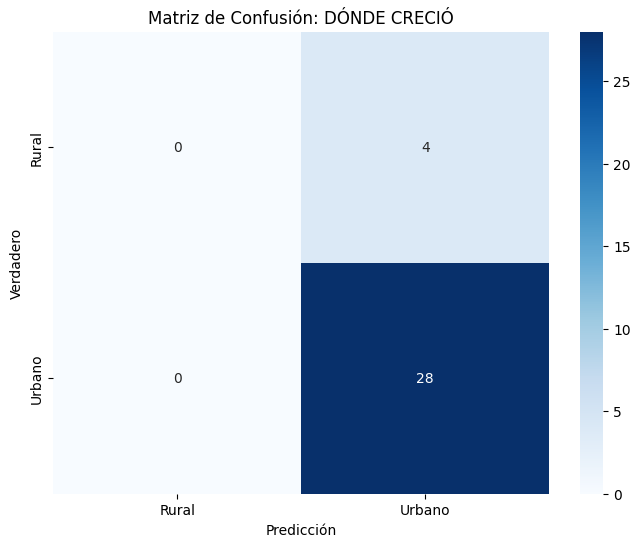


=== Métricas de Ranking ===
Top-5 Accuracy: 0.969
MRR (Mean Reciprocal Rank): 0.909
MAP (Mean Average Precision): 0.879
---------------GRUPO_EDAD----------------------


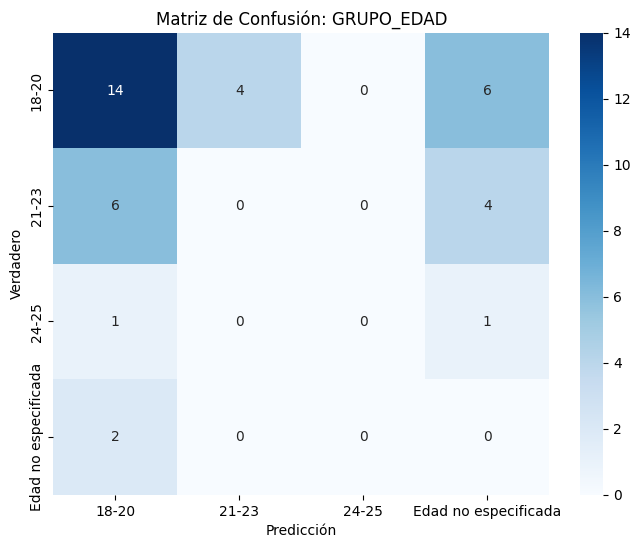


=== Métricas de Ranking ===
Top-5 Accuracy: 0.895
MRR (Mean Reciprocal Rank): 0.571
MAP (Mean Average Precision): 0.549
---------------GRUPO_EDAD_INICIO_FB----------------------


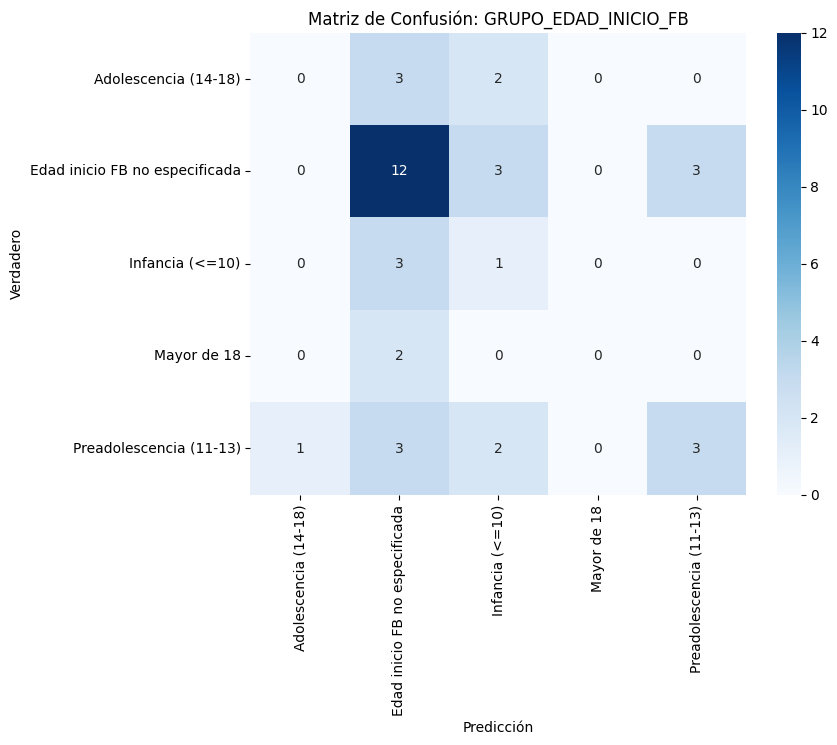


=== Métricas de Ranking ===
Top-5 Accuracy: 0.763
MRR (Mean Reciprocal Rank): 0.532
MAP (Mean Average Precision): 0.499
---------------PARTICIP PUBLICANDO----------------------


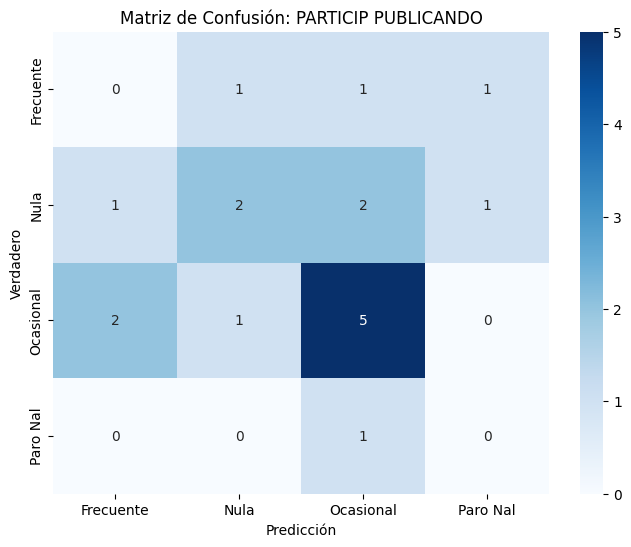


=== Métricas de Ranking ===
Top-5 Accuracy: 0.889
MRR (Mean Reciprocal Rank): 0.661
MAP (Mean Average Precision): 0.605
---------------DISCURSO----------------------


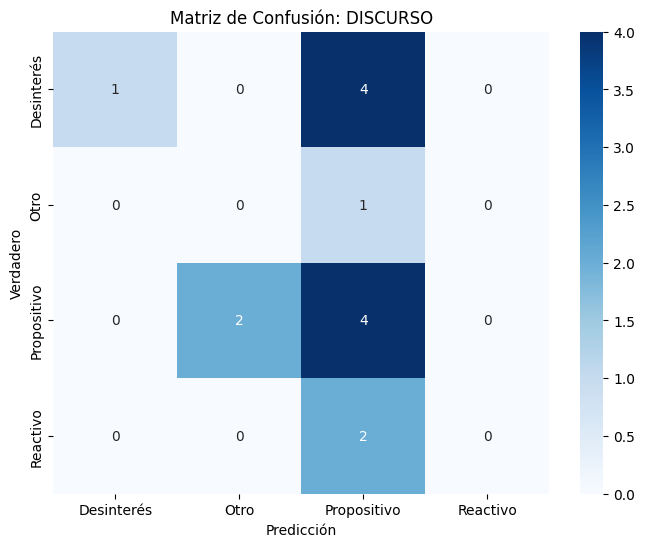


=== Métricas de Ranking ===
Top-5 Accuracy: 0.643
MRR (Mean Reciprocal Rank): 0.419
MAP (Mean Average Precision): 0.406
---------------IDEOLOGÍA POL----------------------


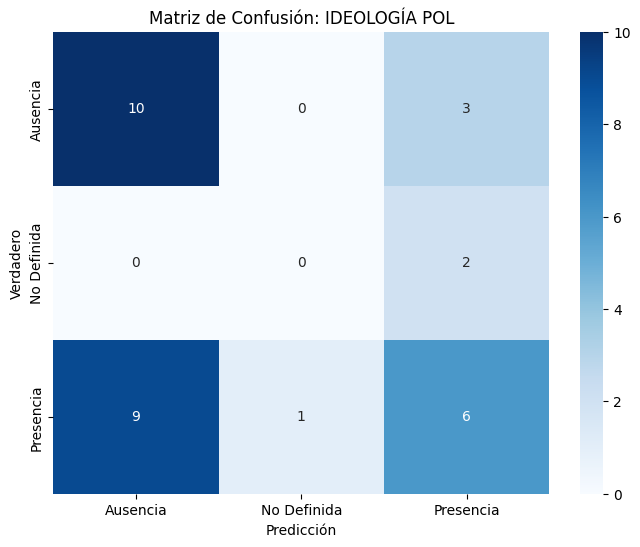


=== Métricas de Ranking ===
Top-5 Accuracy: 0.968
MRR (Mean Reciprocal Rank): 0.703
MAP (Mean Average Precision): 0.671
---------------VIDA OFFLINE----------------------


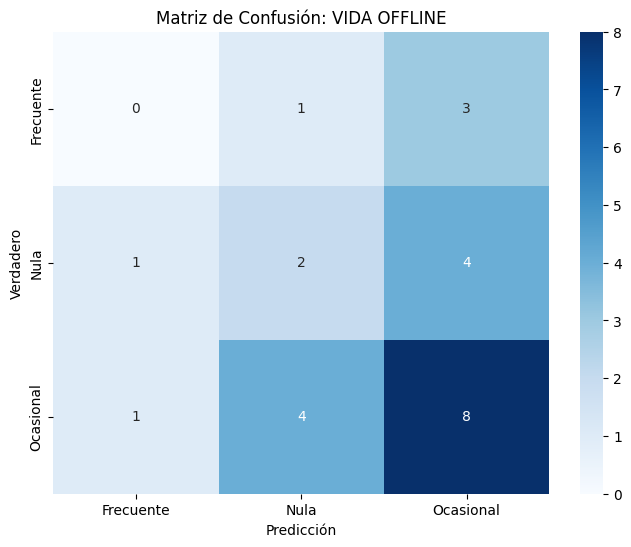


=== Métricas de Ranking ===
Top-5 Accuracy: 0.958
MRR (Mean Reciprocal Rank): 0.659
MAP (Mean Average Precision): 0.635
---------------ACCESO REDES----------------------


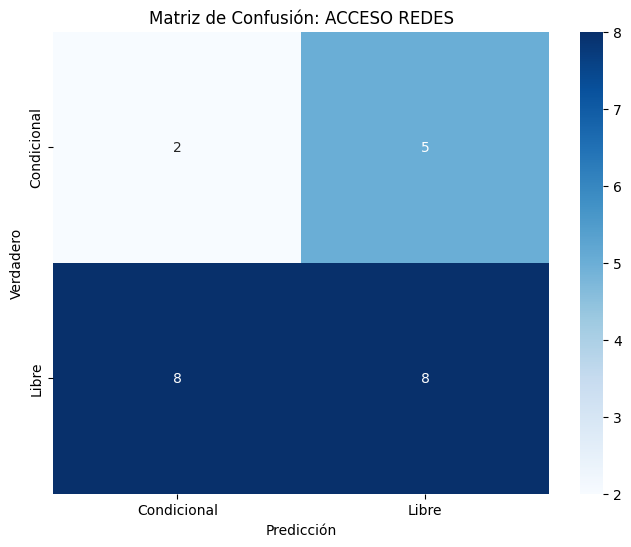


=== Métricas de Ranking ===
Top-5 Accuracy: 0.913
MRR (Mean Reciprocal Rank): 0.594
MAP (Mean Average Precision): 0.604
---------------TIPO FAM1----------------------


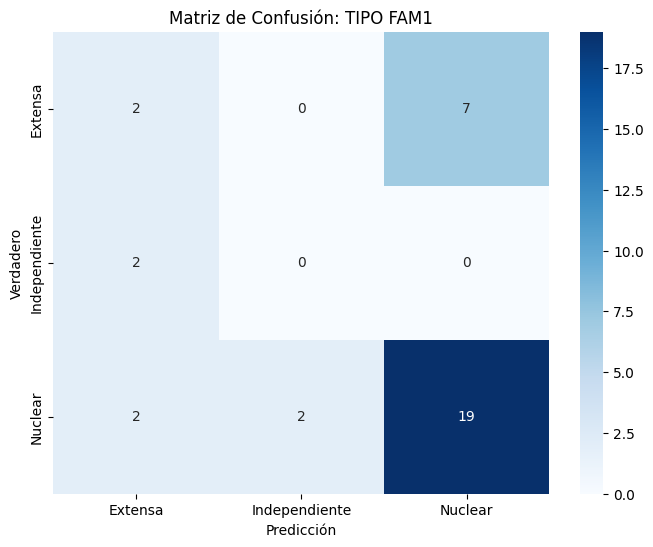


=== Métricas de Ranking ===
Top-5 Accuracy: 0.912
MRR (Mean Reciprocal Rank): 0.684
MAP (Mean Average Precision): 0.664
---------------TIPO RELACIÓN FAM2 (COHESIÓN)----------------------


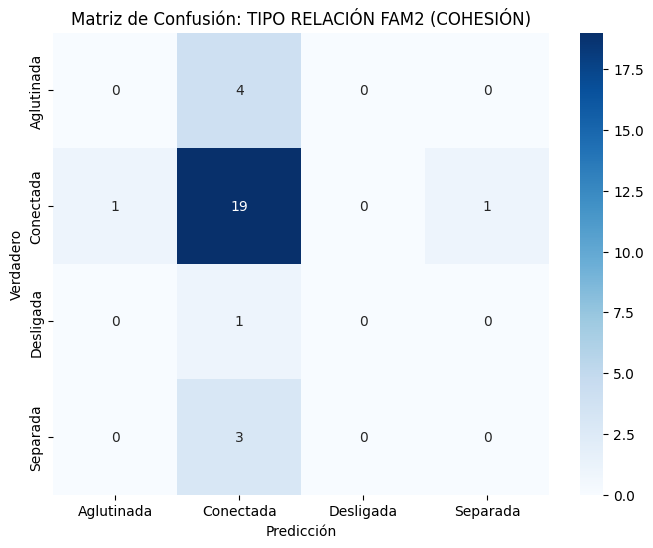


=== Métricas de Ranking ===
Top-5 Accuracy: 0.759
MRR (Mean Reciprocal Rank): 0.563
MAP (Mean Average Precision): 0.554
---------------EXAHUSTIVIDAD----------------------


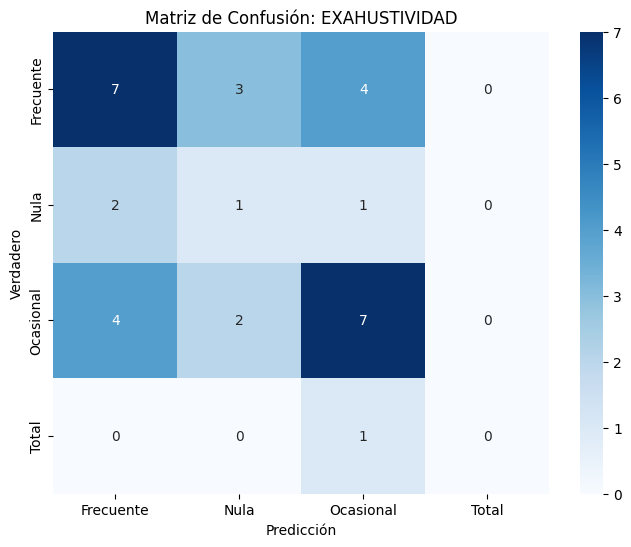


=== Métricas de Ranking ===
Top-5 Accuracy: 0.875
MRR (Mean Reciprocal Rank): 0.557
MAP (Mean Average Precision): 0.553
---------------INTENCIÓN DE VOTO----------------------


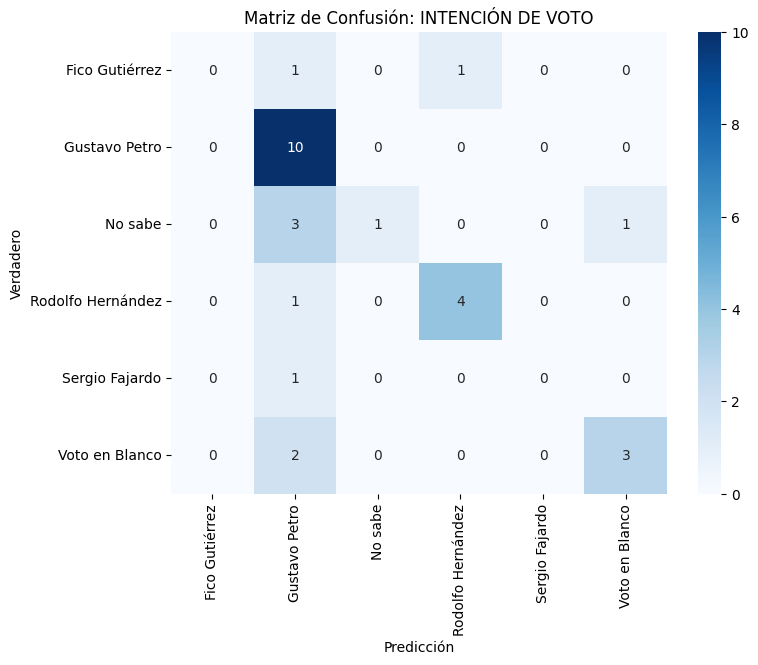


=== Métricas de Ranking ===
Top-5 Accuracy: 0.821
MRR (Mean Reciprocal Rank): 0.730
MAP (Mean Average Precision): 0.675


In [13]:
for key in validacion.keys():
    print(f"---------------{key}----------------------")
    generar_matriz_confusion(validacion[key], key)

# Intento de automatización sin matriz

In [ ]:
mapeo_preguntas = {
    'DÓNDE CRECIÓ': {
        'pregunta': '¿Dónde creció la persona?',
        'respuestas': {
            'Urbano': 'El sujeto relata una infancia en un entorno urbano como una ciudad o barrio, con calles pavimentadas, edificios, escuelas cercanas y acceso a transporte o servicios.',
            'Rural': 'El sujeto menciona haber crecido en una zona rural como una vereda o finca, con contacto con la naturaleza, animales, cultivos'
        }
        
    },
    'GRUPO_EDAD': {
        'pregunta': 'La persona tiene una edad comprendida en el rango de',
        'respuestas': {
            '18-20': '18 a 20 años',
            '21-23': '21 a 23 años',
            '24-25': '24 a 25 años',
            'Edad no especificada': 'edad no especificada'
        }
    },
    'GRUPO_EDAD_INICIO_FB': {
        'pregunta': 'La persona comenzó a usar Facebook durante su',
        'respuestas': {
            'Infancia (<=10)': 'infancia (antes de los 11 años)',
            'Preadolescencia (11-13)': 'preadolescencia (entre 11 y 13 años)',
            'Adolescencia (14-18)': 'adolescencia (entre 14 y 18 años)',
            'Mayor de 18': 'adultez (después de los 18 años)',
            'Edad inicio FB no especificada': 'edad de inicio en Facebook no especificada'
        }
    },
    'PARTICIP PUBLICANDO': {
        'pregunta': 'La frecuencia con que la persona publica o reacciona en redes sociales es',
        'respuestas': {
            'Total': 'muy alta, está constantemente activa',
            'Frecuente': 'activa varias veces a la semana',
            'Ocasional': 'pocas veces o cuando algo le llama la atención',
            'Nula': 'casi nunca publica o reacciona',
            'Paro Nal': 'principalmente activa durante el paro nacional'
        }
    },
    'DISCURSO': {
        'pregunta': '¿Qué tipo de discurso sostiene la persona en redes?',
        'respuestas': {
            'Propositivo': 'Expone ideas constructivas, soluciones o reflexiones orientadas al cambio o a mejorar una situación en sus publicaciones.',
            'Reactivo': 'Responde o reacciona frente a ideas ajenas, con posturas defensivas o críticas ante temas específicos.',
            'Otro': 'Su forma de comunicarse en redes no se ajusta claramente a un estilo propositivo ni reactivo.',
            'Desinterés': 'No expresa ideas, posturas o contenido relevante en redes, mostrando falta de interés temático o participación discursiva.'
        }
    },
    'IDEOLOGÍA POL': {
        'pregunta': 'La expresión de posturas políticas en redes es',
        'respuestas': {
            'Presencia': 'explícita y visible',
            'Ausencia': 'inexistente o neutral',
            'No Definida': 'ambigua o difícil de identificar'
        }
    },
    'VIDA OFFLINE': {
        'pregunta': '¿Qué nivel de participación política tiene fuera de redes?',
        'respuestas': {
            'Total': 'Participa activamente en espacios presenciales como marchas, colectivos, reuniones o iniciativas políticas.',
            'Frecuente': 'Tiene una participación regular en escenarios políticos presenciales.',
            'Ocasional': 'Se vincula a veces en actividades políticas fuera de internet.',
            'Nula': 'No participa en política de forma presencial ni en espacios sociales análogos.'
        }
    },
    'ACCESO REDES': {
        'pregunta': 'El acceso a internet y tecnología es',
        'respuestas': {
            'Libre': 'sin restricciones ni limitaciones',
            'Parcial': 'limitado en tiempo o dispositivos',
            'Condicional': 'sujeto a condiciones externas',
        }
    },
    'TIPO FAM1': {
        'pregunta': 'La estructura familiar del hogar es',
        'respuestas': {
            'Nuclear': 'padres y/o hermanos solamente',
            'Extensa': 'incluye abuelos, tíos u otros familiares',
            'Independiente': 'vive solo por decisión o necesidad',
            'Monoparental': 'madre o padre como único cuidador'
        }
    },
    'TIPO RELACIÓN FAM2 (COHESIÓN)': {
        'pregunta': '¿Cómo es el nivel de conexión emocional con la familia?',
        'respuestas': {
            'Conectada': 'Mantiene vínculos afectivos cercanos con sus familiares, con buena comunicación y apoyo mutuo.',
            'Desligada': 'La relación familiar es cordial pero cada quien lleva su vida de forma independiente.',
            'Separada': 'Existe poca relación emocional o interacción entre los miembros del hogar.',
            'Aglutinada': 'Hay una conexión emocional extremadamente fuerte, con mucha dependencia y poca autonomía entre miembros.'
        }
    },
    'EXAHUSTIVIDAD': {
        'pregunta': '¿Qué tanto tiempo usa Facebook al día?',
        'respuestas': {
            'Total': 'Usa Facebook más de 6 horas al día, con un nivel alto de consumo de contenido.',
            'Frecuente': 'Usa Facebook entre 2 y 6 horas al día como parte de su rutina diaria.',
            'Ocasional': 'Revisa Facebook como máximo una hora al día, de forma poco constante.',
            'Nula': 'No utiliza Facebook o lo hace de forma marginal.'
        }
    },
    'INTENCIÓN DE VOTO': {
        'pregunta': '¿Cuál es la intención de voto de la persona?',
        'respuestas': {
            'Gustavo Petro': 'Manifiesta que votaría por Gustavo Petro en las elecciones.',
            'Fico Gutiérrez': 'Manifiesta que votaría por Fico Gutiérrez.',
            'Sergio Fajardo': 'Manifiesta que votaría por Sergio Fajardo.',
            'Rodolfo Hernández': 'Manifiesta que votaría por Rodolfo Hernández.',
            'Voto en Blanco': 'Manifiesta que votaría en blanco, sin apoyar a ningún candidato.',
            'No sabe': 'No tiene una decisión clara sobre su voto o no quiere responder.'
        }
    }
}


In [60]:
# === CARGAR EXCEL CON INFORMACIÓN DE SUJETOS ===
df_excel = pd.read_excel(PATH_EXCEL)
id_sujetos = df_excel["ID SUJETO"].unique()

# === FUNCIÓN PARA ENCONTRAR CATEGORÍA MÁS SIMILAR A UN FRAGMENTO ===
def predecir_categoria(fragmento, pregunta_key, model):
    opciones = mapeo_preguntas[pregunta_key]["respuestas"]
    descripciones = list(opciones.values())
    nombres = list(opciones.keys())
    
    query_emb = model.encode("query: " + fragmento, convert_to_tensor=True)
    opciones_emb = model.encode(["passage: " + desc for desc in descripciones], convert_to_tensor=True)

    similitudes = util.cos_sim(query_emb, opciones_emb)[0]
    mejor_idx = similitudes.argmax().item()
    return nombres[mejor_idx], similitudes[mejor_idx].item()

In [61]:
# === PROCESAR ENTREVISTAS Y PREDECIR PARA CADA SUJETO Y PREGUNTA ===
resultados = []

for sujeto in id_sujetos:
    path_doc = os.path.join(PATH_ENTREVISTAS, f"{sujeto}.docx")
    if not os.path.exists(path_doc):
        print(f"[!] No se encuentra entrevista de {sujeto}")
        continue

    fragmentos = cargar_entrevista(path_doc)

    for pregunta_key, config in mapeo_preguntas.items():
        pregunta = config["pregunta"]

        # Buscar el fragmento más similar a la pregunta
        fragmentos_codificados = model.encode(["passage: " + f for f in fragmentos], convert_to_tensor=True).to(device)
        pregunta_emb = model.encode("query: " + pregunta, convert_to_tensor=True).to(device)
        
        if fragmentos_codificados.size(0) == 0:
            print("La lista de fragmentos está vacía o no se codificó correctamente.")
            continue
            
        similitudes = util.cos_sim(pregunta_emb, fragmentos_codificados)[0]
        idx_mejor = similitudes.argmax().item()
        mejor_fragmento = fragmentos[idx_mejor]

        # Predecir la categoría más similar
        categoria_pred, score = predecir_categoria(mejor_fragmento, pregunta_key, model)

        resultados.append({
            "ID SUJETO": sujeto,
            "Pregunta": pregunta_key,
            "Fragmento": mejor_fragmento,
            "Predicción": categoria_pred,
            "Similitud": round(score, 4)
        })

# === CONVERTIR RESULTADOS A DATAFRAME Y MOSTRAR ===
df_resultados = pd.DataFrame(resultados)

La lista de fragmentos está vacía o no se codificó correctamente.
La lista de fragmentos está vacía o no se codificó correctamente.
La lista de fragmentos está vacía o no se codificó correctamente.
La lista de fragmentos está vacía o no se codificó correctamente.
La lista de fragmentos está vacía o no se codificó correctamente.
La lista de fragmentos está vacía o no se codificó correctamente.
La lista de fragmentos está vacía o no se codificó correctamente.
La lista de fragmentos está vacía o no se codificó correctamente.
La lista de fragmentos está vacía o no se codificó correctamente.
La lista de fragmentos está vacía o no se codificó correctamente.
La lista de fragmentos está vacía o no se codificó correctamente.
La lista de fragmentos está vacía o no se codificó correctamente.


In [64]:
df_resultados.to_excel('automatizar_sin_matriz.xlsx', index=False)

In [ ]:
df2= pd.read_excel('automatizar_sin_matriz.xlsx')
df2

,ID SUJETO,Pregunta,Fragmento,Predicción,Similitud
0,H02,DÓNDE CRECIÓ,passage: E: ¿Sobre qué era la publicación? / P...,Rural,0.7589
1,H02,GRUPO_EDAD,passage: E: Y ¿con qué tipo de contenido? / P:...,Edad no especificada,0.7914
2,H02,GRUPO_EDAD_INICIO_FB,"passage: E: Instagram y WhatsApp. / P: Ok, eee...",Edad inicio FB no especificada,0.8270
3,H02,PARTICIP PUBLICANDO,"passage: E: Ah, bueno. Eeee, qué uso le das, e...",Ocasional,0.8253
4,H02,DISCURSO,passage: E: Ok. Y ahora estás más pendiente en...,Otro,0.7895
...,...,...,...,...,...
1471,M64,ACCESO REDES,"passage: E: Ok, cuéntame un poco si te acuerda...",Primogénito Digital,0.8161
1472,M64,TIPO FAM1,passage: E: Es congresista / P: (risas) bueno ...,Monoparental,0.7917
1473,M64,TIPO RELACIÓN FAM2 (COHESIÓN),passage: E: Ok ¿Cómo es tu relaciona con ellos...,Separada,0.8023
1474,M64,EXAHUSTIVIDAD,"passage: E: ¿Cuánto tiempo, más o menos? / P: ...",Frecuente,0.8536


In [ ]:
df2.columns

Index(['ID SUJETO', 'Pregunta', 'Fragmento', 'Predicción', 'Similitud'], dtype='object')

In [ ]:
df.columns

Index(['ID SUJETO', 'EDAD', 'DÓNDE CRECIÓ', 'EDAD INICIO FB', 'ACCESO REDES',
       'TIPO FAM1', 'TIPO RELACIÓN FAM2 (COHESIÓN)', 'PARTIC. FAM REDES',
       'PART FAM EN POLIT', 'EXAHUSTIVIDAD', 'PARTICIP PUBLICANDO', 'DISCURSO',
       'IDEOLOGÍA POL', 'VIDA OFFLINE', 'INTENCIÓN DE VOTO', 'OBSERVACIONES',
       'GRUPO_EDAD', 'EDAD_INICIO_FB_NUM', 'GRUPO_EDAD_INICIO_FB'],
      dtype='object')

In [ ]:
# Asegúrate de tener df_original indexado por 'ID SUJETO'
df_original_indexed = df.set_index("ID SUJETO")

# Función para obtener el valor real desde df_original en la columna que corresponde a la pregunta
def obtener_etiqueta_real(fila):
    sujeto = fila["ID SUJETO"]
    columna_pregunta = fila["Pregunta"]
    try:
        return df_original_indexed.loc[sujeto, columna_pregunta]
    except KeyError:
        return None  # O usa algún valor por defecto o marcadores de error

# Aplicar la función al df_resultados
df2["Etiqueta Real"] = df2.apply(obtener_etiqueta_real, axis=1)


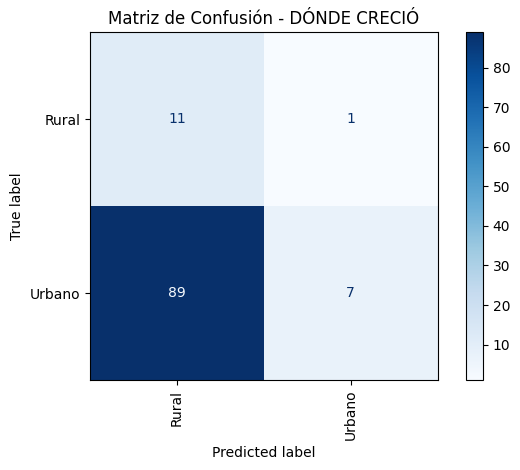

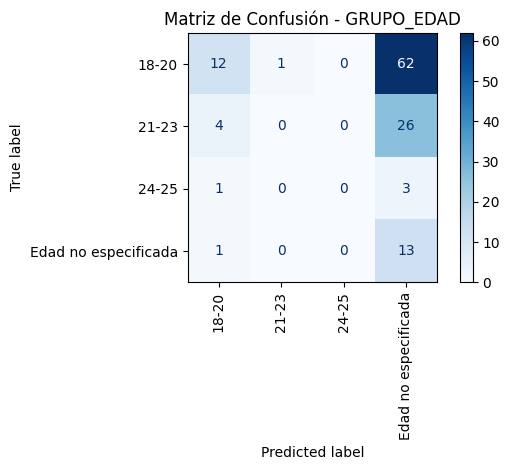

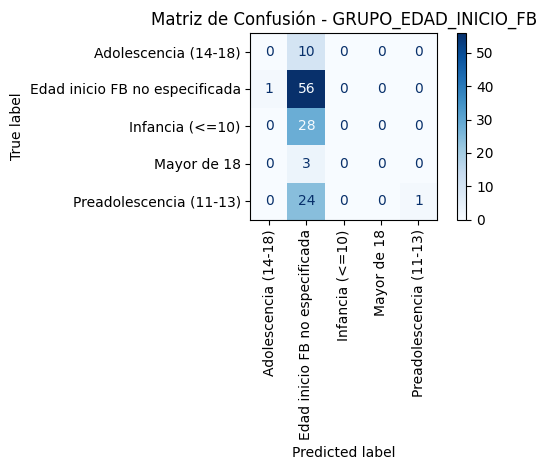

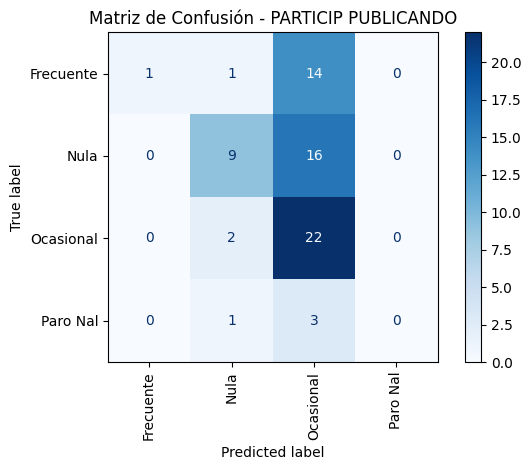

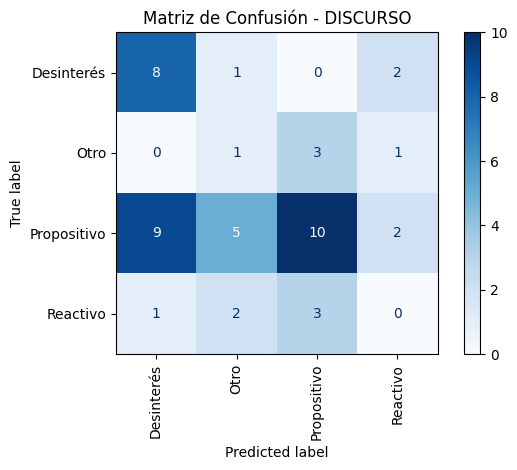

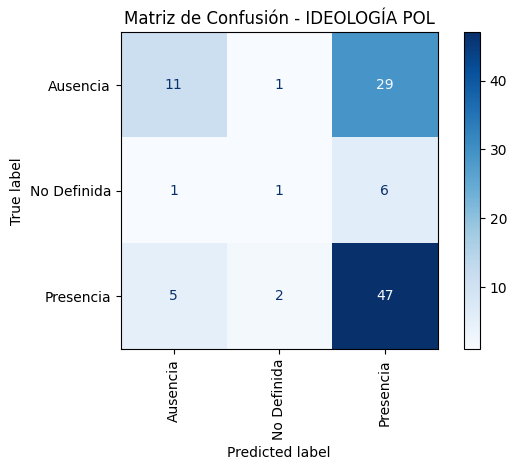

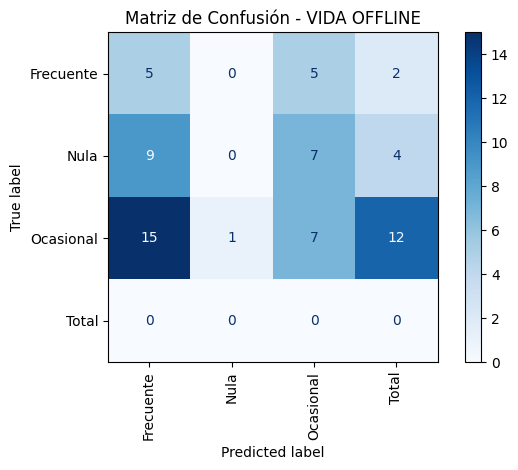

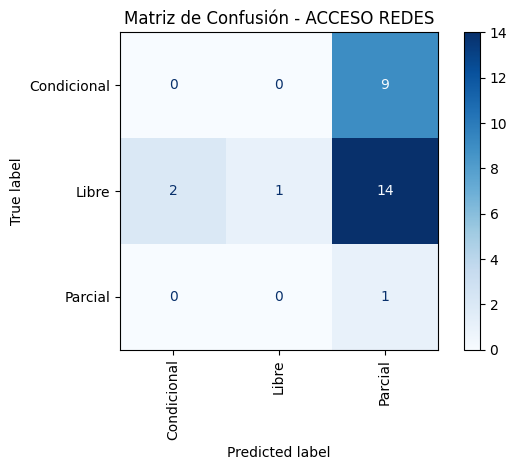

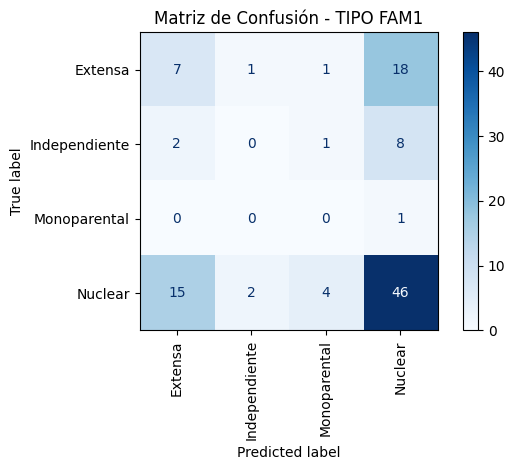

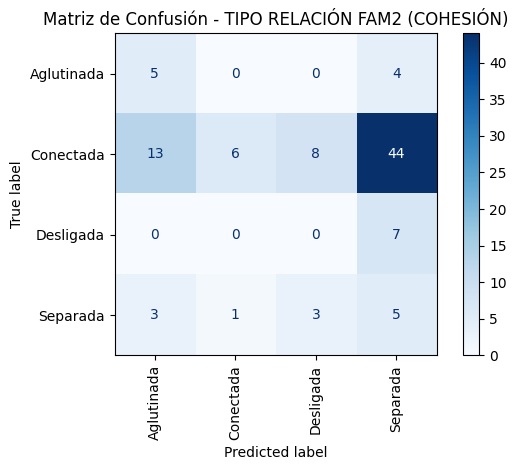

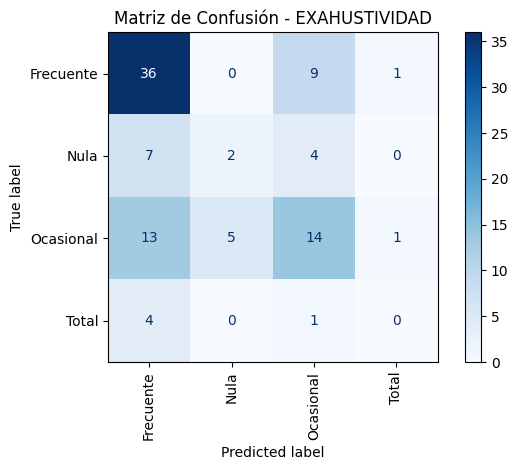

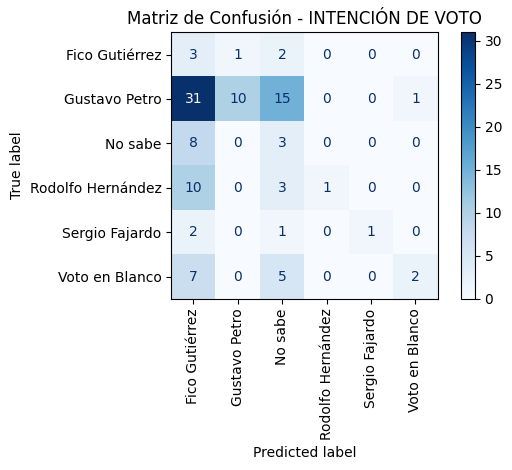

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Asegúrate de que 'ID SUJETO' sea el índice en df_original
df_original_indexed = df.set_index("ID SUJETO")

# Filtrar las preguntas únicas del DataFrame de resultados
preguntas_unicas = df2["Pregunta"].unique()

# Recorrer cada pregunta
for pregunta in preguntas_unicas:
    # Filtrar predicciones para esta pregunta
    df_pregunta = df2[df2["Pregunta"] == pregunta].copy()

    # Obtener etiquetas reales desde df_original
    etiquetas_reales = []
    for idx, fila in df_pregunta.iterrows():
        sujeto = fila["ID SUJETO"]
        try:
            etiqueta_real = df_original_indexed.loc[sujeto, pregunta]
        except KeyError:
            etiqueta_real = None
        etiquetas_reales.append(etiqueta_real)

    df_pregunta["Etiqueta Real"] = etiquetas_reales

    # Eliminar filas sin etiqueta real
    df_pregunta = df_pregunta.dropna(subset=["Etiqueta Real"])
    
    if df_pregunta.empty:
        print(f"\n[!] Sin datos válidos para la pregunta: {pregunta}")
        continue

    # Convertir a string para evitar problemas de etiquetas no compatibles
    df_pregunta["Etiqueta Real"] = df_pregunta["Etiqueta Real"].astype(str)
    df_pregunta["Predicción"] = df_pregunta["Predicción"].astype(str)

    # Si la pregunta es ACCESO REDES, quitar la opción "Primogénito Digital"
    if pregunta == "ACCESO REDES":
        df_pregunta = df_pregunta[
            (df_pregunta["Etiqueta Real"] != "Primogénito Digital") &
            (df_pregunta["Predicción"] != "Primogénito Digital")
        ]

    if df_pregunta.empty:
        print(f"\n[!] Sin datos válidos (tras filtrar 'Primogénito Digital') para: {pregunta}")
        continue

    y_true = df_pregunta["Etiqueta Real"]
    y_pred = df_pregunta["Predicción"]
    labels = sorted(set(y_true) | set(y_pred))

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(xticks_rotation=90, cmap='Blues')
    plt.title(f"Matriz de Confusión - {pregunta}")
    plt.tight_layout()
    plt.show()
